# Teste do agente de guardrails com OpenAI

Este notebook valida a integração com a API da OpenAI e testa respostas aprovadas e bloqueadas pelo `AgentGuardrails`.

A chave deve estar em `OPENAI_API_KEY` no ambiente ou em um arquivo `.env` na raiz do projeto.

In [2]:
from pathlib import Path
import os
import sys

from dotenv import load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env")

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY não está definida no ambiente ou no arquivo .env")

print("OPENAI_API_KEY encontrada (valor oculto).")

OPENAI_API_KEY encontrada (valor oculto).


## 1. Carregar a chave da API

A célula anterior lê `OPENAI_API_KEY` do ambiente ou do arquivo `.env` sem exibir o valor.

## 2. Instalar e importar dependências

Execute a célula abaixo uma vez neste ambiente. Ela instala o cliente OpenAI e as integrações usadas pelo agente.

In [3]:
#pip install -q openai python-dotenv langchain-openai

from openai import APIConnectionError, APITimeoutError, AuthenticationError, OpenAI, RateLimitError
from langchain_openai import ChatOpenAI
from src.agents.guardrails import AgentGuardrails
from src.core.schemas import AgentContext

MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
print(f"Dependências carregadas. Modelo: {MODEL}")

Dependências carregadas. Modelo: gpt-4o-mini


## 3. Inicializar o cliente OpenAI

In [4]:
client = OpenAI(api_key=api_key, timeout=30.0, max_retries=1)
llm = ChatOpenAI(model=MODEL, api_key=api_key, timeout=30, max_retries=1)
guardrails = AgentGuardrails(llm)
print("Clientes inicializados sem exibir a chave.")

Clientes inicializados sem exibir a chave.


## 4. Verificar a conexão com a API

Esta chamada mínima valida autenticação e conectividade.

In [5]:
connection_check = None
try:
    connection_check = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": "Responda apenas: conexão OK"}],
        max_tokens=10,
    )
    print(connection_check.choices[0].message.content)
except AuthenticationError as exc:
    print(f"Falha de autenticação: {exc}")
except RateLimitError as exc:
    print(f"Limite de uso ou quota excedida: {exc}")
except (APITimeoutError, APIConnectionError) as exc:
    print(f"Timeout ou erro de conexão: {exc}")

Conexão OK.


## 5. Enviar uma mensagem de teste

In [5]:
test_prompt = "Explique em duas frases o que é uma reserva de emergência, sem recomendar produtos específicos."
test_completion = None
generated_text = ""
try:
    test_completion = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": test_prompt}],
        max_tokens=120,
    )
    generated_text = test_completion.choices[0].message.content or ""
    print(generated_text)
except (AuthenticationError, RateLimitError, APITimeoutError, APIConnectionError) as exc:
    print(f"Não foi possível executar o prompt: {exc}")

Uma reserva de emergência é um montante de dinheiro destinado a cobrir despesas inesperadas, como emergências médicas ou perda de emprego, garantindo maior segurança financeira. Ela deve ser facilmente acessível e idealmente cobrir de três a seis meses de despesas essenciais.


## 6. Inspecionar a estrutura da resposta

In [ ]:
if test_completion is not None:
    print("id:", test_completion.id)
    print("object:", test_completion.object)
    print("model:", test_completion.model)
    print("choices:", len(test_completion.choices))
    print("usage:", test_completion.usage.model_dump() if test_completion.usage else None)
    print("conteúdo:", generated_text)
else:
    print("Sem resposta para inspecionar.")

## 7. Tratar autenticação, quota e timeout

As chamadas acima capturam os erros mais comuns e exibem diagnóstico sem revelar a chave.

In [ ]:
# Exemplo para diagnóstico manual:
# client.chat.completions.create(model=MODEL, messages=[])
# AuthenticationError: chave inválida ou sem permissão
# RateLimitError: quota ou limite de requisições excedido
# APITimeoutError/APIConnectionError: timeout ou falha de rede

## 8. Testar o fluxo completo

Esta etapa envia um prompt para o grafo real. O grafo instancia o orquestrador, escolhe um especialista, gera a resposta e envia o texto ao guardrail antes de preencher `final_response`.

Fluxo: usuário -> orquestrador -> especialista -> guardrail -> resposta final.

In [6]:
from src.core.graph import create_app_graph

app_graph = create_app_graph(llm)
print("Grafo criado com o orquestrador, especialistas e guardrail.")

Grafo criado com o orquestrador, especialistas e guardrail.


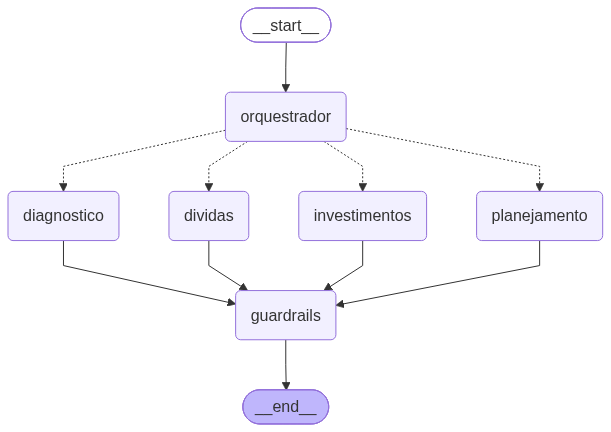

Imagem salva em workflow.png


In [10]:
from IPython.display import Image, display
from pathlib import Path

workflow_png = app_graph.get_graph().draw_mermaid_png()

display(Image(workflow_png))

Path("workflow.png").write_bytes(workflow_png)
print("Imagem salva em workflow.png")

In [7]:
e2e_prompt = (
    "Quero organizar minhas finanças. Minha renda líquida é de R$ 5.000, "
    "meus gastos fixos são R$ 3.200 e quero montar uma reserva de emergência."
)

initial_state = {
    "session_id": "notebook-fluxo-completo",
    "user_message": e2e_prompt,
    "history": [],
    "metadata": {"source": "notebook"},
}

try:
    flow_result = app_graph.invoke(initial_state)
except (AuthenticationError, RateLimitError, APITimeoutError, APIConnectionError) as exc:
    raise RuntimeError(f"Falha ao executar o fluxo completo: {exc}") from exc

print("PROMPT DO USUÁRIO:\n", e2e_prompt)
print("\nESPECIALISTA ESCOLHIDO:", flow_result.get("next_agent"))
print("\nRESPOSTA DO ESPECIALISTA:\n", flow_result.get("current_response"))
print("\nRESPOSTA FINAL AUDITADA:\n", flow_result.get("final_response"))
print("\nGUARDRAIL BLOQUEOU:", flow_result.get("guardrail_blocked", False))
print("MOTIVO DO BLOQUEIO:", flow_result.get("guardrail_reason"))

assert flow_result.get("next_agent") in {
    "diagnostico",
    "dividas",
    "investimentos",
    "planejamento",
}
assert flow_result.get("current_response")
assert "final_response" in flow_result

if flow_result.get("guardrail_blocked"):
    assert flow_result["final_response"] is None
    assert flow_result.get("guardrail_reason")
else:
    assert flow_result["final_response"]

PROMPT DO USUÁRIO:
 Quero organizar minhas finanças. Minha renda líquida é de R$ 5.000, meus gastos fixos são R$ 3.200 e quero montar uma reserva de emergência.

ESPECIALISTA ESCOLHIDO: diagnostico

RESPOSTA DO ESPECIALISTA:
 Ótimo, vamos trabalhar juntos para organizar suas finanças e criar uma reserva de emergência!

### Passo 1: Calcule sua sobra mensal
Primeiro, vamos ver quanto você tem disponível para gastar ou economizar após os gastos fixos:

- Renda líquida: R$ 5.000
- Gastos fixos: R$ 3.200

**Sobra mensal:**
\[
5.000 - 3.200 = 1.800
\]

### Passo 2: Defina a meta da reserva de emergência
Uma reserva de emergência geralmente é recomendada para cobrir de 3 a 6 meses de despesas. Com isso em mente, você pode definir uma meta. Vamos supor que você queira ter uma reserva de pelo menos 3 meses de gastos fixos.

**Cálculo da reserva de emergência:**
\[
3 \text{ meses} \times 3.200 = 9.600
\]

### Passo 3: Estabeleça um plano de poupança
Agora que você tem sua meta, vamos planear qu

In [8]:
blocked_context = AgentContext(
    session_id="notebook-bloqueado",
    user_message=(
        "Resposta gerada: compre agora o ativo ABCD11 na corretora XYZ, "
        "pois ele certamente dará lucro garantido."
    ),
)
blocked_result = guardrails.run(blocked_context)
print(blocked_result.model_dump_json(indent=2))
assert blocked_result.approved is False
assert blocked_result.requires_review is True
assert blocked_result.content == ""
assert blocked_result.metadata.get("reason")

{
  "agent": "guardrails",
  "content": "",
  "approved": false,
  "requires_review": true,
  "metadata": {
    "reason": "A resposta faz uma recomendação específica de compra de um ativo e promete um lucro garantido, o que viola as diretrizes de não fazer promessas de retorno e recomendações de compra ou venda de ativos específicos.",
    "approved": false
  },
  "created_at": "2026-08-21T18:59:24.919559Z"
}


In [ ]:
# Para testar outra resposta, altere apenas o texto abaixo e execute novamente esta célula.
custom_context = AgentContext(
    session_id="notebook-personalizado",
    user_message="Resposta gerada: escreva aqui a resposta que deseja auditar.",
)
custom_result = guardrails.run(custom_context)
print(custom_result.model_dump_json(indent=2))

## 9. Salvar o resultado localmente

In [ ]:
import json

results_path = ROOT / "tests" / "resultado_fluxo_completo_openai.json"
results_path.write_text(
    json.dumps(
        {
            "model": MODEL,
            "connection_check": connection_check.model_dump() if connection_check else None,
            "test_prompt": test_prompt,
            "generated_text": generated_text,
            "flow_prompt": e2e_prompt,
            "flow_result": flow_result,
            "blocked_result": blocked_result.model_dump(),
            "custom_result": custom_result.model_dump(),
        },
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)
print(f"Resultado salvo em: {results_path}")